In [1]:
from calc_script import create_stats_df
from calc_script import create_plant_summary
from calc_script import create_a_summary_plot_ss_to_ss_comparison, create_a_summary_plot_rop_to_ss_comparison
from calc_script import create_all_products_summary_plot_ss_to_ss_comparison, create_all_products_summary_plot_rop_to_ss_comparison
from calc_script import export_df_to_excel_file
from calc_script import get_input_files
from IPython.display import display, Markdown
import pandas as pd

In [2]:
START_DATE = '2025-10-20'
END_DATE = '2026-04-20'
# START_DATE = '2025-04-20'
# END_DATE = '2025-07-20'
GET_ALL_DATES_FROM_MB51 = False

PRODUCTION_PLANT = '2101'

# 95% -> k = 1.96 (most common choice)
# 96% -> k = 2,05 (best choice)
# 99% -> k = 2.33
K_PARAMETER = 2.05

STD_MAD_TRESHOLD = 2.5

PRODUCT_GROUPS = [
    'L1K',
    'R4_R7_H',
    'R6_R8_H'
]


In [3]:
exchange_rates = {
    'EUR': 1.0,
    'PLN': 0.23,  # Przykład: 1 PLN = 0.23 EUR
    'CZK': 0.04   # Przykład: 1 CZK = 0.04 EUR
}

input_directory = r"P:\Technisch\PLANY PRODUKCJI\PLANIŚCI\PP_TOOLS_TEMP_FILES\15_SAFETY_STOCKS_CALCULATIONS\input"

mb51_path = r"P:\Technisch\PLANY PRODUKCJI\PLANIŚCI\PP_TOOLS_TEMP_FILES\15_SAFETY_STOCKS_CALCULATIONS\input\L1K_Consumption.XLSX"
zsbe_path = r"P:\Technisch\PLANY PRODUKCJI\PLANIŚCI\PP_TOOLS_TEMP_FILES\15_SAFETY_STOCKS_CALCULATIONS\input\L1K_items_and_parameters.XLSX"
no_ss_items_path = r"P:\Technisch\PLANY PRODUKCJI\PLANIŚCI\PP_TOOLS_TEMP_FILES\15_SAFETY_STOCKS_CALCULATIONS\helper_files\no_ss_items.xlsx"

output_directory = r"P:\Technisch\PLANY PRODUKCJI\PLANIŚCI\PP_TOOLS_TEMP_FILES\15_SAFETY_STOCKS_CALCULATIONS\output"

In [4]:
all_files = get_input_files(input_directory, PRODUCT_GROUPS)

## Calculating: L1K

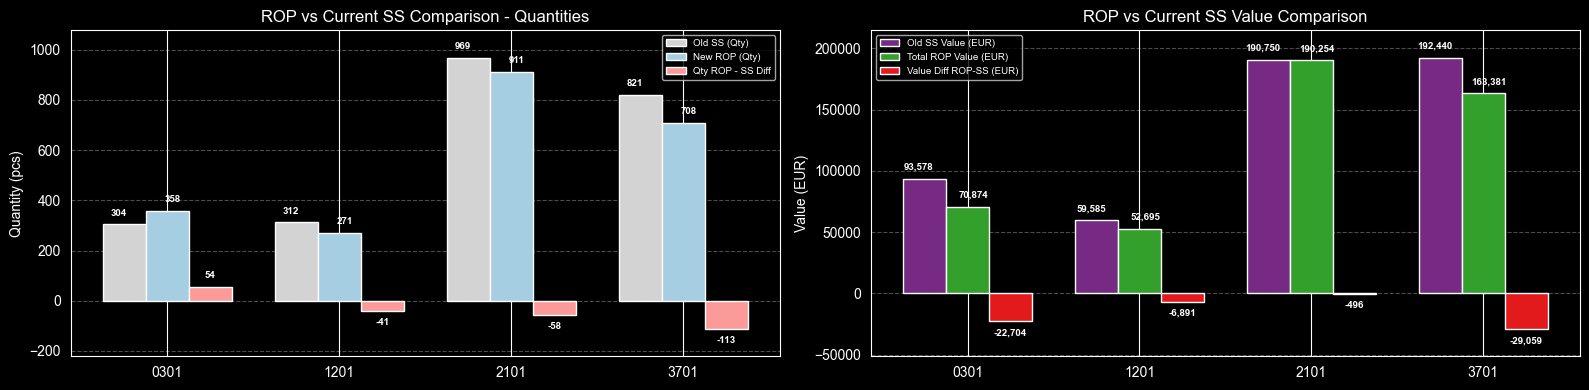

## Calculating: R4_R7_H

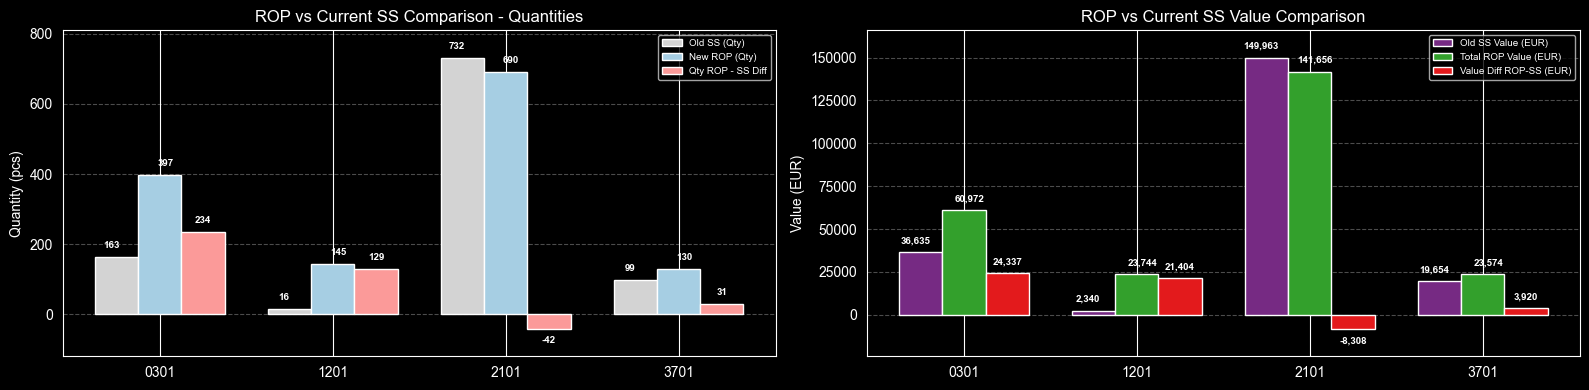

## Calculating: R6_R8_H

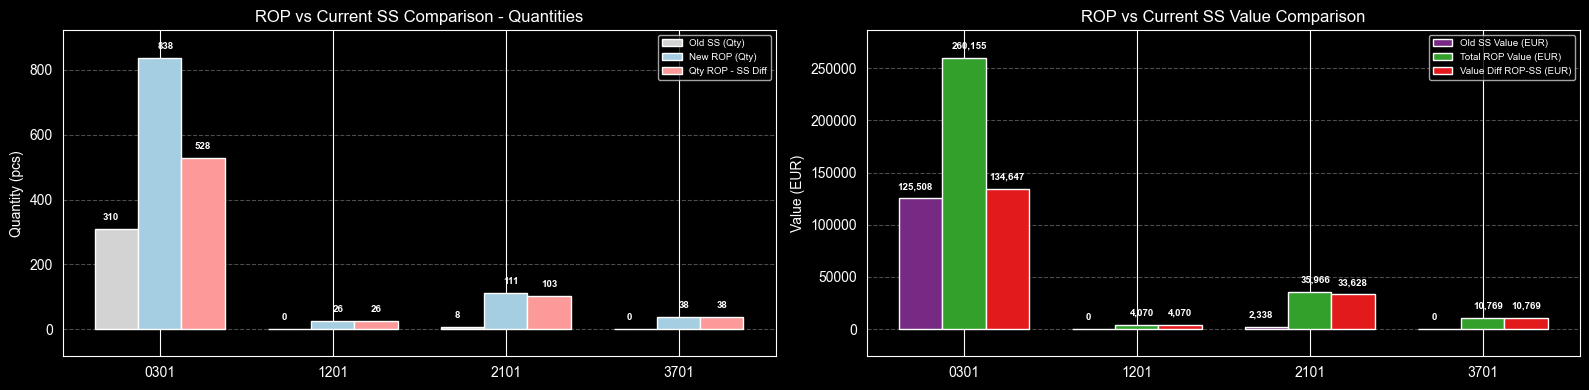

## All products summary

,product_group,Total New SS (Qty),Total Old SS (Qty),Total SS - SS Qty Diff,Total ROP - SS Qty Diff,Total New SS Value [EUR],Total ROP Value [EUR],Total Old SS Value [EUR],Total Reorder Point (Qty),Value Difference SS - SS [EUR],Value Difference ROP - SS [EUR]
0,L1K,1443,2406,-963,-158,307280,477204,536353,2248,-229074,-59150
1,R4_R7_H,837,1010,-173,352,154636,249946,208592,1362,-53957,41353
2,R6_R8_H,569,318,251,695,178324,310960,127846,1013,50478,183114


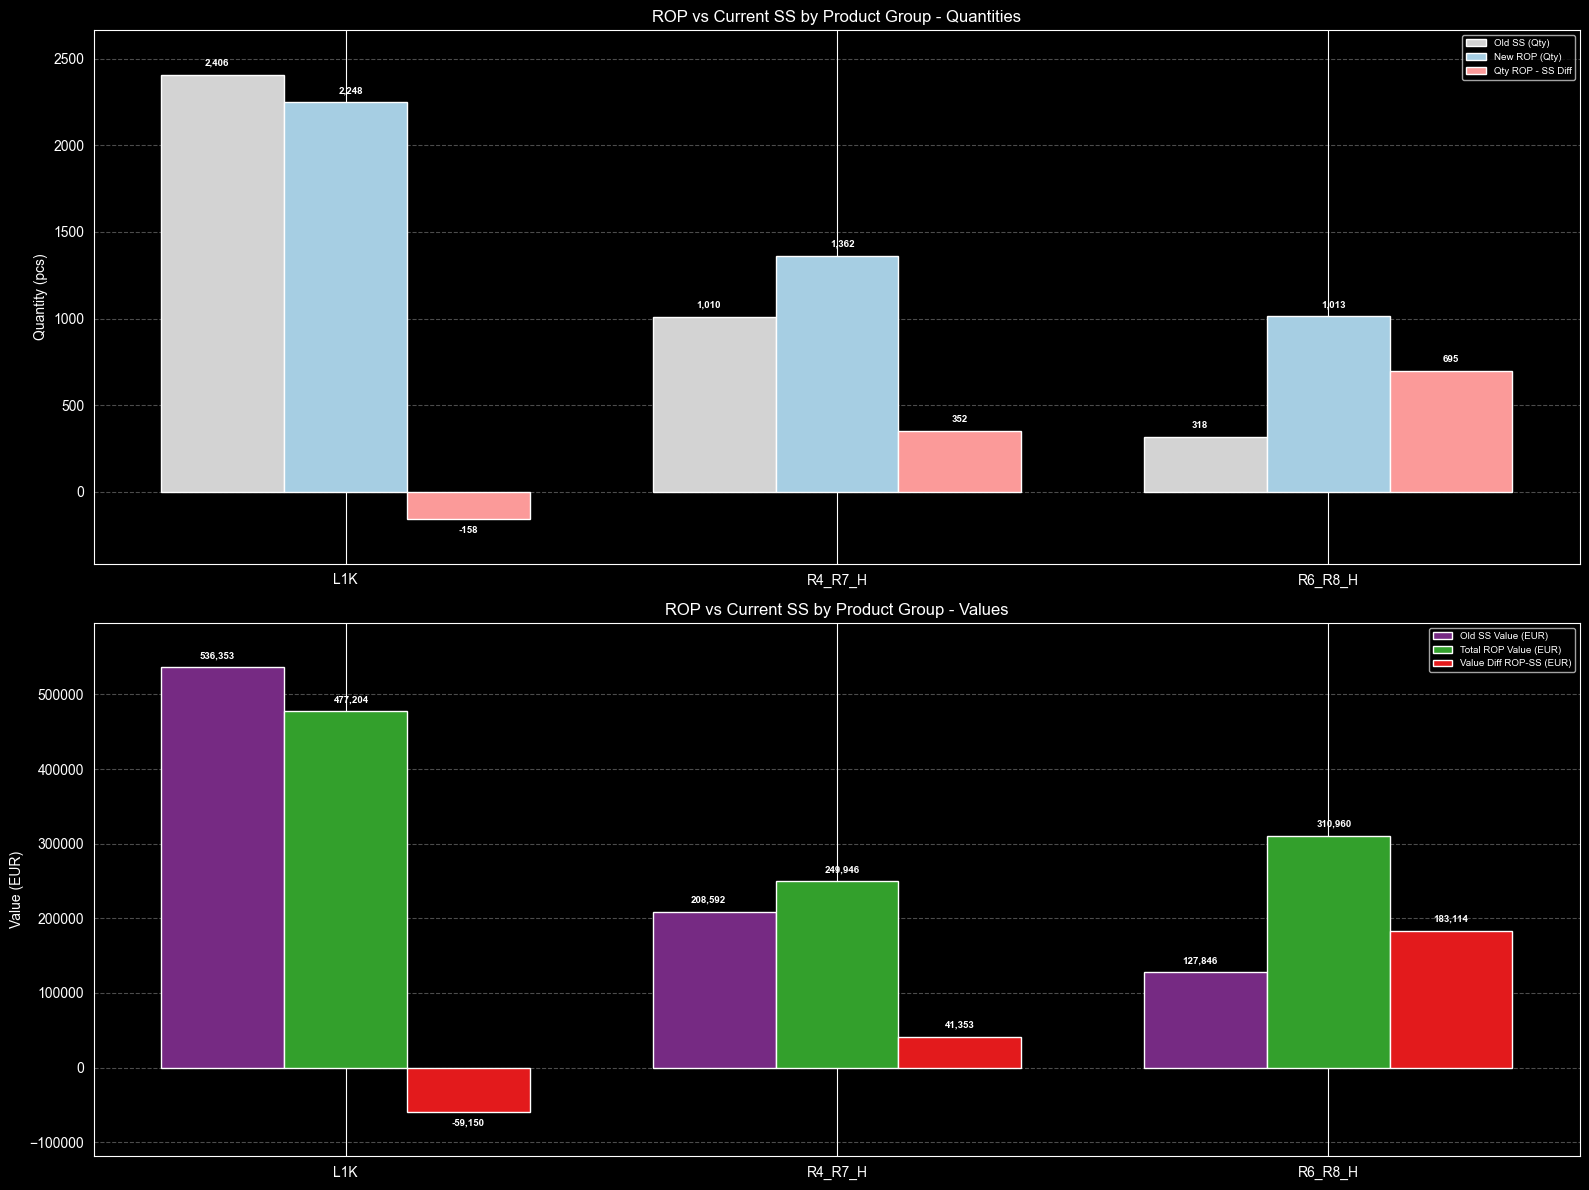

In [5]:
all_products_summary_rows = []

for prd_group, (mb51_f_path, zsbe_f_path) in all_files.items():
    display(Markdown(f"## Calculating: {prd_group}"))

    stats_df = create_stats_df(mb51_f_path, zsbe_f_path, no_ss_items_path, PRODUCTION_PLANT, GET_ALL_DATES_FROM_MB51, START_DATE, END_DATE, K_PARAMETER, exchange_rates, STD_MAD_TRESHOLD)
    plant_summary = create_plant_summary(stats_df)

    product_summary = plant_summary.select_dtypes(include="number").sum().to_dict()
    product_summary["product_group"] = prd_group
    all_products_summary_rows.append(product_summary)

    # fig_ss = create_a_summary_plot_ss_to_ss_comparison(plant_summary)
    fig_rop = create_a_summary_plot_rop_to_ss_comparison(plant_summary)
    # display(fig_ss)
    display(fig_rop)
    output_file_name = f"{prd_group}_ss_summary.xlsx"
    export_df_to_excel_file(stats_df, fr"{output_directory}\{output_file_name}")

all_products_summary = pd.DataFrame(all_products_summary_rows)
all_products_summary = all_products_summary[["product_group"] + [col for col in all_products_summary.columns if col != "product_group"]]

display(Markdown("## All products summary"))
display(all_products_summary)

fig_all_products = create_all_products_summary_plot_rop_to_ss_comparison(all_products_summary, False)
display(fig_all_products)